In [2]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import numpy as np
import pandas as pd
import copy 
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
!pip install scikit-learn


  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 35.5 MB/s eta 0:00:00 0:00:01
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.3/30.3 MB 42.9 MB/s eta 0:00:00a 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)


In [7]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

##Generate Synthetic data with noise

In [12]:
X, y = make_moons(n_samples=800, noise=0.2, random_state=42)
X[0:3]

array([[ 1.4916376 , -0.12415845],
       [ 1.4007517 , -0.52063633],
       [ 0.85806768,  0.26889893]])

<function matplotlib.pyplot.show(close=None, block=None)>

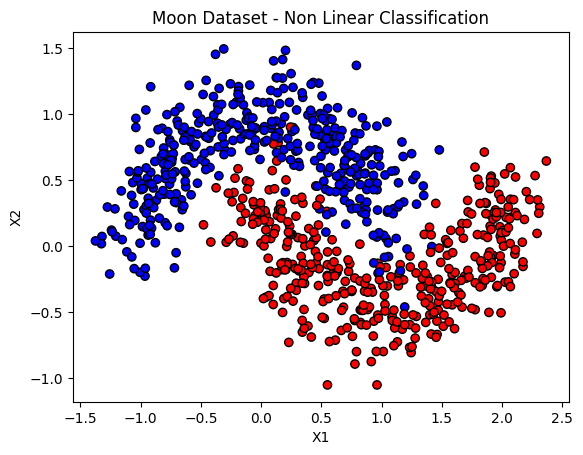

In [18]:
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolors='k')
plt.title("Moon Dataset - Non Linear Classification")
plt.xlabel("X1")
plt.ylabel("X2")

plt.show

TASK : Make a Classifier using Multi Lpaer Perceptron to classify the datapoints correctly

Simple Multi Layer Perceptron 
1. 2 input features 
2. 2 neurons in hidden layer 
3. 2 outputs for binary classification 


Step 1 : Preparing data for Neural Network 

1. Split data into train and test split 
2. Scale data to zero mean and unit variance 

In [19]:
from sklearn.neural_network import MLPClassifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

For Neural Netwroks always scale the data.

In [21]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

Step 2: Building the Neural Network.

Set Model Architecture

    Activation function to be used in hidden Neuron.

    Hidden Layer Size and Number of Neuron.

    Maximum number of iteration.

In [ ]:
mlp= MLPClassifier(hidden_layer_sizes=(2,), activation='relu', max_iter=200, random_state=42) #Identify linear value

Step 3: Train the model

In [23]:
#Train 
mlp.fit(X_train_std, y_train)

MLPClassifier(hidden_layer_sizes=(2,), random_state=42)

Step 4: Test Set Evaluation: Accuracy and Confusion Matrix

In [24]:
y_pred = mlp.predict(X_test_std)
print("Test Accuracy Score :" , accuracy_score(y_test, y_pred))

Test Accuracy Score : 0.8833333333333333


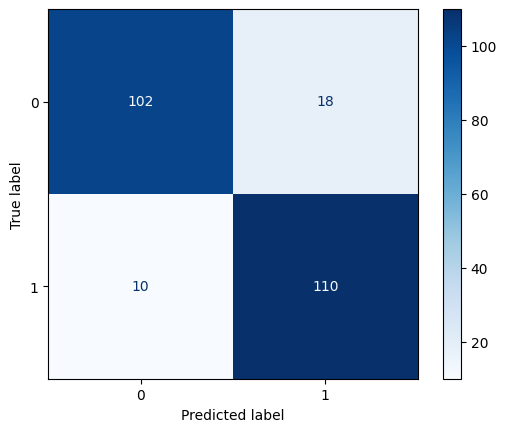

In [25]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))
disp.plot(cmap=plt.cm.Blues)
plt.show()

Visualise the decion boundary

In [26]:
correct =  y_pred == y_test 
incorrect = ~correct